# 🚦 Week 3 — Ensemble Model Comparison
## Random Forest vs AdaBoost vs XGBoost
**Dataset:** Metro Interstate Traffic Volume  
**Task:** Regression — Predict `traffic_volume`

---
### 📋 Notebook Structure
1. Install & Import Libraries
2. Load & Explore the Dataset
3. Feature Engineering
4. Pre-processing (Encoding + Scaling)
5. Train/Test Split
6. Model Training
   - Random Forest
   - AdaBoost
   - XGBoost
7. Evaluation & Comparison
8. Visualisations
9. Conclusion

## 1. 📦 Install & Import Libraries

In [10]:

!pip install xgboost --quiet

In [11]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')


from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing  import LabelEncoder, StandardScaler
from sklearn.metrics        import (mean_absolute_error,
                                    mean_squared_error,
                                    r2_score)

from sklearn.ensemble import RandomForestRegressor, AdaBoostRegressor
from xgboost          import XGBRegressor


SEED = 42
np.random.seed(SEED)

print('✅ All libraries imported successfully!')

✅ All libraries imported successfully!


## 2. 📂 Load & Explore the Dataset

In [12]:
# ── Upload the file when running in Colab ───────────────────────────
from google.colab import files
uploaded = files.upload()


filename = list(uploaded.keys())[0]
print(f"Uploaded file: {filename}")


import io
try:
    df = pd.read_csv(io.BytesIO(uploaded[filename]), compression='gzip')
    print("Read as gzip CSV")
except Exception:
    df = pd.read_csv(io.BytesIO(uploaded[filename]))
    print("Read as plain CSV")

print(f'Dataset loaded: {df.shape[0]:,} rows × {df.shape[1]} columns')
df.head()

Saving Metro_Interstate_Traffic_Volume.csv to Metro_Interstate_Traffic_Volume (3).csv
Uploaded file: Metro_Interstate_Traffic_Volume (3).csv
Read as plain CSV
Dataset loaded: 48,204 rows × 9 columns


,holiday,temp,rain_1h,snow_1h,clouds_all,weather_main,weather_description,date_time,traffic_volume
0,NaN,288.28,0.0,0.0,40,Clouds,scattered clouds,2012-10-02 09:00:00,5545
1,NaN,289.36,0.0,0.0,75,Clouds,broken clouds,2012-10-02 10:00:00,4516
2,NaN,289.58,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 11:00:00,4767
3,NaN,290.13,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 12:00:00,5026
4,NaN,291.14,0.0,0.0,75,Clouds,broken clouds,2012-10-02 13:00:00,4918


In [13]:
# ── Basic info ───────────────────────────────────────────────────────
print('=== Data Types ===')
print(df.dtypes)
print('\n=== Missing Values ===')
print(df.isnull().sum())
print('\n=== Statistical Summary ===')
df.describe()

=== Data Types ===
holiday                 object
temp                   float64
rain_1h                float64
snow_1h                float64
clouds_all               int64
weather_main            object
weather_description     object
date_time               object
traffic_volume           int64
dtype: object

=== Missing Values ===
holiday                48143
temp                       0
rain_1h                    0
snow_1h                    0
clouds_all                 0
weather_main               0
weather_description        0
date_time                  0
traffic_volume             0
dtype: int64

=== Statistical Summary ===


,temp,rain_1h,snow_1h,clouds_all,traffic_volume
count,48204.000000,48204.000000,48204.000000,48204.000000,48204.000000
mean,281.205870,0.334264,0.000222,49.362231,3259.818355
std,13.338232,44.789133,0.008168,39.015750,1986.860670
min,0.000000,0.000000,0.000000,0.000000,0.000000
25%,272.160000,0.000000,0.000000,1.000000,1193.000000
50%,282.450000,0.000000,0.000000,64.000000,3380.000000
75%,291.806000,0.000000,0.000000,90.000000,4933.000000
max,310.070000,9831.300000,0.510000,100.000000,7280.000000


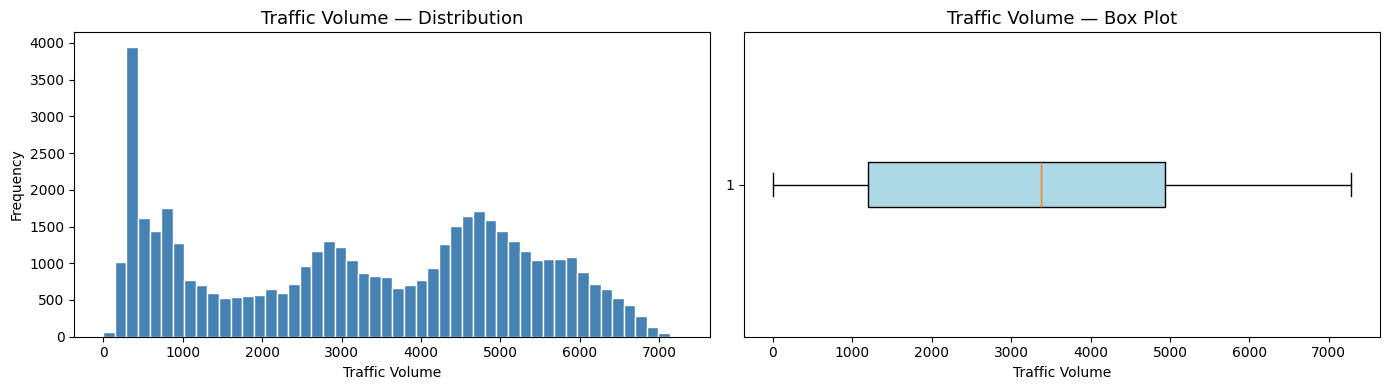

Target range: 0 – 7280


In [14]:
# ── Target variable distribution ─────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(df['traffic_volume'], bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Traffic Volume — Distribution', fontsize=13)
axes[0].set_xlabel('Traffic Volume')
axes[0].set_ylabel('Frequency')

axes[1].boxplot(df['traffic_volume'], vert=False, patch_artist=True,
                boxprops=dict(facecolor='lightblue'))
axes[1].set_title('Traffic Volume — Box Plot', fontsize=13)
axes[1].set_xlabel('Traffic Volume')

plt.tight_layout()
plt.savefig('target_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Target range: {df["traffic_volume"].min()} – {df["traffic_volume"].max()}')

## 3. 🔧 Feature Engineering

In [15]:
# ── Parse datetime & extract cyclic time features ────────────────────
df['date_time'] = pd.to_datetime(df['date_time'])

df['hour']        = df['date_time'].dt.hour
df['day_of_week'] = df['date_time'].dt.dayofweek   # 0=Mon … 6=Sun
df['month']       = df['date_time'].dt.month
df['year']        = df['date_time'].dt.year
df['is_weekend']  = (df['day_of_week'] >= 5).astype(int)

# Cyclic encoding for hour (so 23 & 0 are 'close')
df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)

# Cyclic encoding for month
df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)

# ── Fill missing holiday values ───────────────────────────────────────
df['holiday'] = df['holiday'].fillna('None')
df['is_holiday'] = (df['holiday'] != 'None').astype(int)

print('✅ Feature engineering done!')
print(f'   New columns added: hour, day_of_week, month, year, is_weekend,'
      f' hour_sin, hour_cos, month_sin, month_cos, is_holiday')
df[['date_time','hour','day_of_week','month','is_weekend','is_holiday']].head()

✅ Feature engineering done!
   New columns added: hour, day_of_week, month, year, is_weekend, hour_sin, hour_cos, month_sin, month_cos, is_holiday


,date_time,hour,day_of_week,month,is_weekend,is_holiday
0,2012-10-02 09:00:00,9,1,10,0,0
1,2012-10-02 10:00:00,10,1,10,0,0
2,2012-10-02 11:00:00,11,1,10,0,0
3,2012-10-02 12:00:00,12,1,10,0,0
4,2012-10-02 13:00:00,13,1,10,0,0


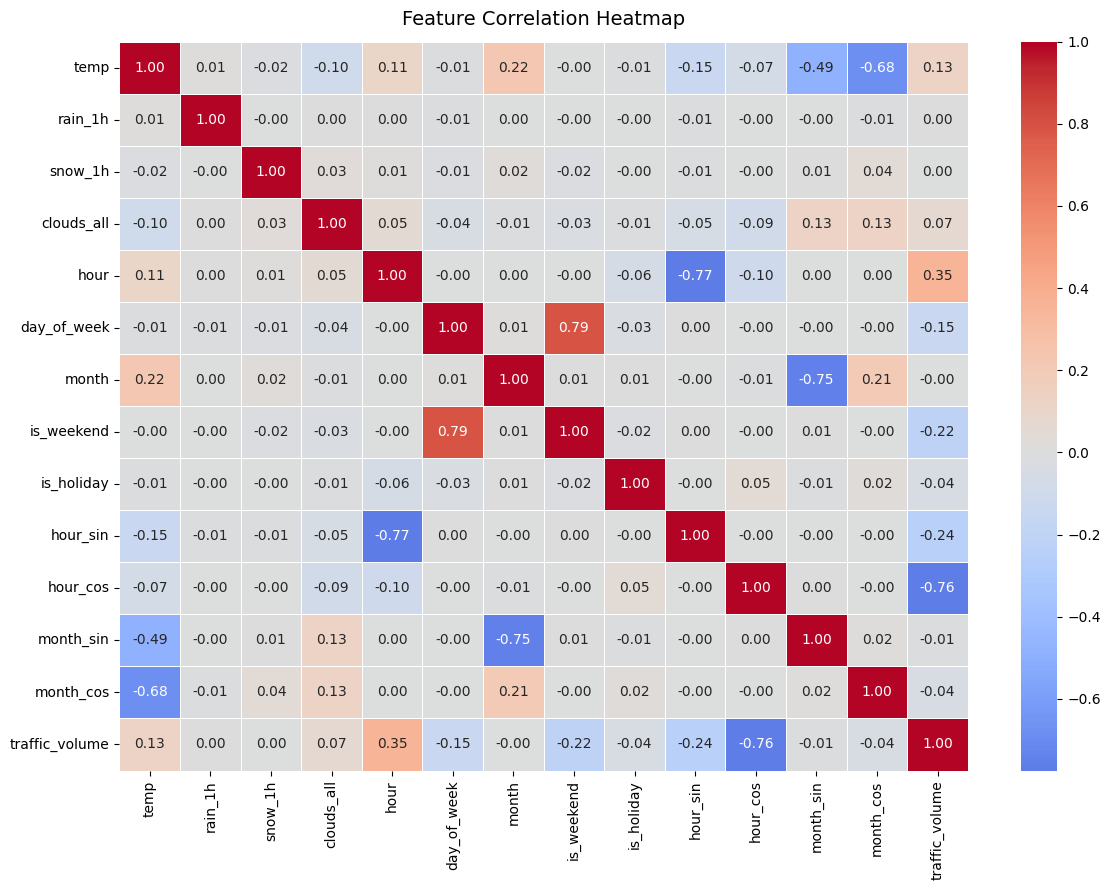

In [16]:
# ── Correlation heatmap (numeric features only) ───────────────────────
num_cols = ['temp','rain_1h','snow_1h','clouds_all','hour','day_of_week',
            'month','is_weekend','is_holiday','hour_sin','hour_cos',
            'month_sin','month_cos','traffic_volume']

plt.figure(figsize=(12, 9))
sns.heatmap(df[num_cols].corr(), annot=True, fmt='.2f',
            cmap='coolwarm', center=0, linewidths=0.5)
plt.title('Feature Correlation Heatmap', fontsize=14, pad=12)
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. 🔄 Pre-processing

In [17]:
# ── Label-encode categorical columns ─────────────────────────────────
le_weather_main = LabelEncoder()
le_weather_desc = LabelEncoder()

df['weather_main_enc'] = le_weather_main.fit_transform(df['weather_main'])
df['weather_desc_enc'] = le_weather_desc.fit_transform(df['weather_description'])

print('Weather main categories:', le_weather_main.classes_)
print('\nWeather desc sample:', le_weather_desc.classes_[:8], '...')

# ── Define final feature set ─────────────────────────────────────────
FEATURES = [
    'temp', 'rain_1h', 'snow_1h', 'clouds_all',
    'hour', 'day_of_week', 'month', 'year',
    'is_weekend', 'is_holiday',
    'hour_sin', 'hour_cos',
    'month_sin', 'month_cos',
    'weather_main_enc', 'weather_desc_enc'
]
TARGET = 'traffic_volume'

X = df[FEATURES]
y = df[TARGET]

print(f'\n✅ Feature matrix shape : {X.shape}')
print(f'   Target vector shape  : {y.shape}')

Weather main categories: ['Clear' 'Clouds' 'Drizzle' 'Fog' 'Haze' 'Mist' 'Rain' 'Smoke' 'Snow'
 'Squall' 'Thunderstorm']

Weather desc sample: ['SQUALLS' 'Sky is Clear' 'broken clouds' 'drizzle' 'few clouds' 'fog'
 'freezing rain' 'haze'] ...

✅ Feature matrix shape : (48204, 16)
   Target vector shape  : (48204,)


## 5. ✂️ Train / Test Split

In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED
)

# ── Scale features (important for AdaBoost base learners) ────────────
scaler  = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f'Training samples : {X_train.shape[0]:,}')
print(f'Test     samples : {X_test.shape[0]:,}')
print(f'Features         : {X_train.shape[1]}')

Training samples : 38,563
Test     samples : 9,641
Features         : 16


## 6. 🤖 Model Training

We train three ensemble methods:
| Model | Core Idea | Parallelisable? |
|-------|-----------|----------------|
| Random Forest | Bagging of many deep Decision Trees | ✅ Yes |
| AdaBoost | Sequential boosting — focuses on hard samples | ❌ No |
| XGBoost | Gradient Boosting with regularisation & speed optimisations | Partially |

### 6a. 🌳 Random Forest

In [19]:
import time

print('Training Random Forest ...', flush=True)
rf_model = RandomForestRegressor(
    n_estimators  = 200,     # number of trees
    max_depth     = 15,      # limit tree depth to reduce overfitting
    min_samples_split = 5,   # minimum samples required to split a node
    min_samples_leaf  = 2,   # minimum samples at a leaf node
    max_features  = 'sqrt',  # features considered at each split  (= √p)
    n_jobs        = -1,      # use all CPU cores
    random_state  = SEED
)

t0 = time.time()
rf_model.fit(X_train, y_train)   # RF doesn't need scaled data
rf_train_time = time.time() - t0

rf_pred = rf_model.predict(X_test)
print(f'✅ Random Forest trained in {rf_train_time:.1f}s')

Training Random Forest ...
✅ Random Forest trained in 18.1s


### 6b. 🚀 AdaBoost

In [20]:
print('Training AdaBoost ...', flush=True)
ada_model = AdaBoostRegressor(
    n_estimators  = 200,       # number of weak learners
    learning_rate = 0.1,       # shrinks each estimator's contribution
    loss          = 'square',  # loss function: 'linear' | 'square' | 'exponential'
    random_state  = SEED
)

t0 = time.time()
ada_model.fit(X_train_sc, y_train)   # AdaBoost benefits from scaled features
ada_train_time = time.time() - t0

ada_pred = ada_model.predict(X_test_sc)
print(f'✅ AdaBoost trained in {ada_train_time:.1f}s')

Training AdaBoost ...
✅ AdaBoost trained in 16.7s


### 6c. ⚡ XGBoost

In [21]:
print('Training XGBoost ...', flush=True)
xgb_model = XGBRegressor(
    n_estimators    = 300,      # number of boosting rounds
    learning_rate   = 0.05,     # step size shrinkage (eta)
    max_depth       = 6,        # maximum tree depth
    subsample       = 0.8,      # fraction of samples per tree
    colsample_bytree= 0.8,      # fraction of features per tree
    reg_alpha       = 0.1,      # L1 regularisation
    reg_lambda      = 1.0,      # L2 regularisation
    eval_metric     = 'rmse',
    random_state    = SEED,
    verbosity       = 0
)

t0 = time.time()
xgb_model.fit(
    X_train, y_train,
    eval_set        = [(X_test, y_test)],
    verbose         = False
)
xgb_train_time = time.time() - t0

xgb_pred = xgb_model.predict(X_test)
print(f'✅ XGBoost trained in {xgb_train_time:.1f}s')

Training XGBoost ...
✅ XGBoost trained in 1.7s


## 7. 📊 Evaluation & Comparison

In [22]:
def evaluate(name, y_true, y_pred, train_time):
    """Return a dict of regression metrics."""
    mae  = mean_absolute_error(y_true, y_pred)
    mse  = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2   = r2_score(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / (y_true + 1e-9))) * 100
    return {
        'Model'          : name,
        'MAE'            : round(mae,  2),
        'MSE'            : round(mse,  2),
        'RMSE'           : round(rmse, 2),
        'R² Score'       : round(r2,   4),
        'MAPE (%)'       : round(mape, 2),
        'Train Time (s)' : round(train_time, 1)
    }

results = [
    evaluate('Random Forest', y_test, rf_pred,  rf_train_time),
    evaluate('AdaBoost',      y_test, ada_pred, ada_train_time),
    evaluate('XGBoost',       y_test, xgb_pred, xgb_train_time),
]

results_df = pd.DataFrame(results).set_index('Model')
print('=' * 65)
print('          MODEL PERFORMANCE COMPARISON')
print('=' * 65)
print(results_df.to_string())
print('=' * 65)
print('\n🏆 Best R²  :', results_df['R² Score'].idxmax())
print('🏆 Best RMSE:', results_df['RMSE'].idxmin())
print('🏆 Best MAE :', results_df['MAE'].idxmin())

          MODEL PERFORMANCE COMPARISON
                  MAE        MSE    RMSE  R² Score  MAPE (%)  Train Time (s)
Model                                                                       
Random Forest  241.32  184155.29  429.13    0.9534     61.43            18.1
AdaBoost       720.11  870153.77  932.82    0.7799     86.97            16.7
XGBoost        228.96  166915.33  408.55    0.9578     51.90             1.7

🏆 Best R²  : XGBoost
🏆 Best RMSE: XGBoost
🏆 Best MAE : XGBoost


## 8. 📈 Visualisations

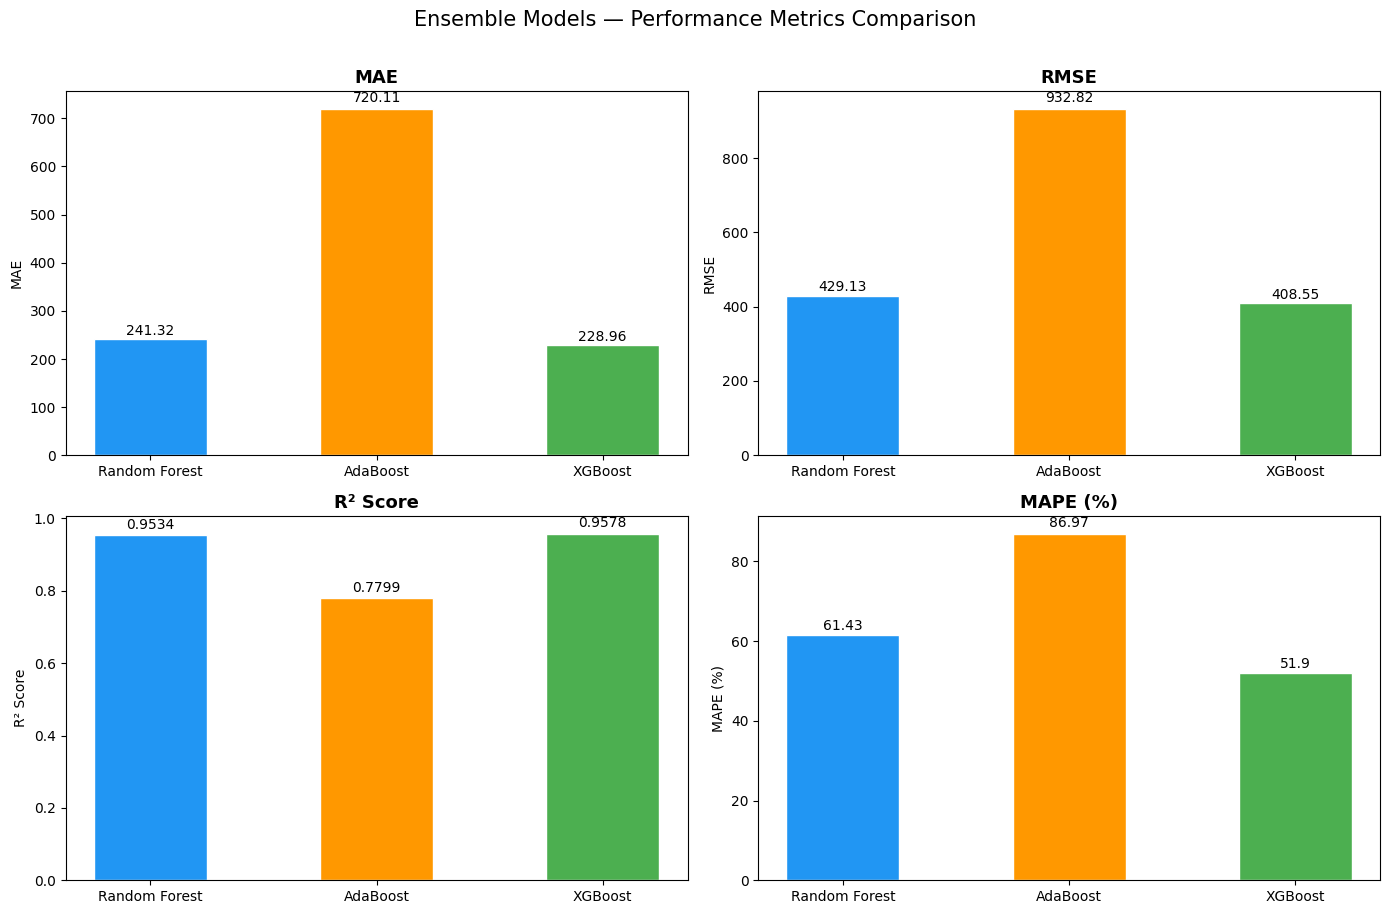

In [23]:
# ── 8a. Side-by-side bar charts for key metrics ───────────────────────
metrics   = ['MAE', 'RMSE', 'R² Score', 'MAPE (%)']
models    = results_df.index.tolist()
colors    = ['#2196F3', '#FF9800', '#4CAF50']

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
axes = axes.flatten()

for i, metric in enumerate(metrics):
    vals = results_df[metric].values
    bars = axes[i].bar(models, vals, color=colors, edgecolor='white', width=0.5)
    axes[i].set_title(metric, fontsize=13, fontweight='bold')
    axes[i].set_ylabel(metric)
    for bar, v in zip(bars, vals):
        axes[i].text(bar.get_x() + bar.get_width()/2,
                     bar.get_height() * 1.01,
                     str(v), ha='center', va='bottom', fontsize=10)

plt.suptitle('Ensemble Models — Performance Metrics Comparison', fontsize=15, y=1.01)
plt.tight_layout()
plt.savefig('metrics_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

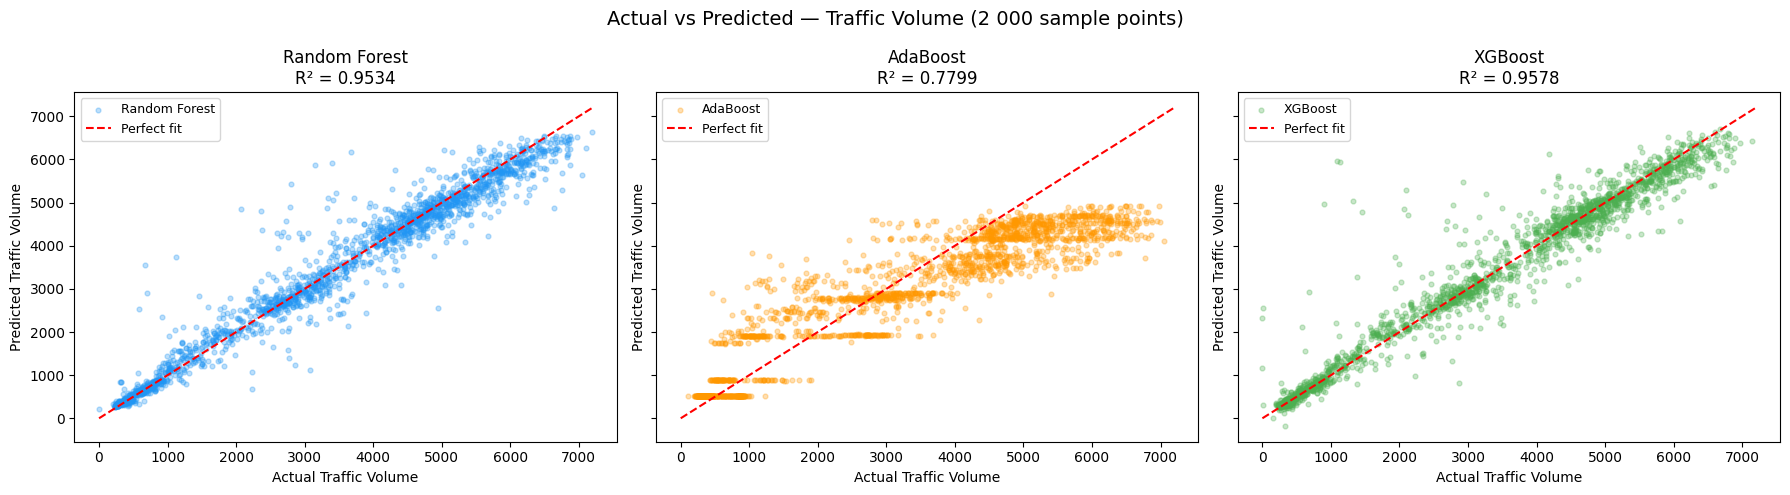

In [24]:
# ── 8b. Actual vs Predicted scatter plots ─────────────────────────────
all_preds = {'Random Forest': rf_pred,
             'AdaBoost'     : ada_pred,
             'XGBoost'      : xgb_pred}

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

for ax, (name, pred), c in zip(axes, all_preds.items(), colors):
    # Sample 2000 points for clarity
    idx = np.random.choice(len(y_test), size=2000, replace=False)
    ax.scatter(y_test.values[idx], pred[idx],
               alpha=0.3, s=12, color=c, label=name)
    lo, hi = y_test.min(), y_test.max()
    ax.plot([lo, hi], [lo, hi], 'r--', lw=1.5, label='Perfect fit')
    ax.set_title(f'{name}\nR² = {r2_score(y_test, pred):.4f}', fontsize=12)
    ax.set_xlabel('Actual Traffic Volume')
    ax.set_ylabel('Predicted Traffic Volume')
    ax.legend(fontsize=9)

plt.suptitle('Actual vs Predicted — Traffic Volume (2 000 sample points)', fontsize=14)
plt.tight_layout()
plt.savefig('actual_vs_predicted.png', dpi=150, bbox_inches='tight')
plt.show()

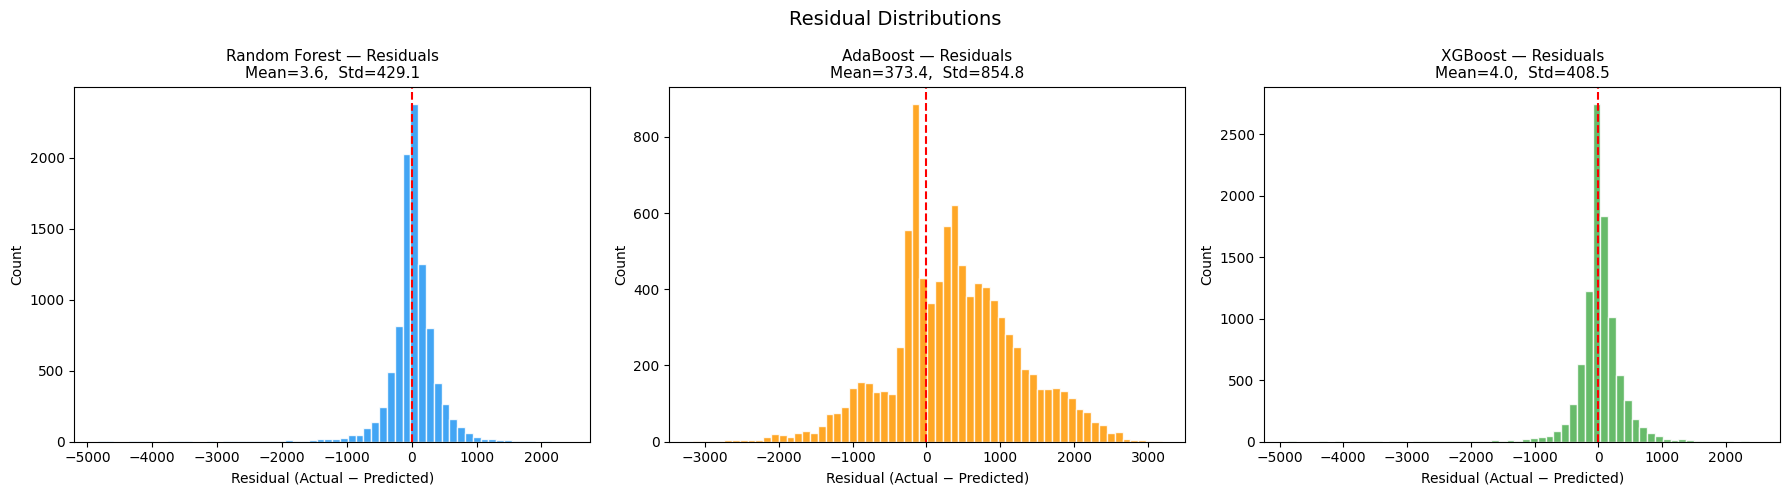

In [25]:
# ── 8c. Residual distribution plots ──────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (name, pred), c in zip(axes, all_preds.items(), colors):
    residuals = y_test.values - pred
    ax.hist(residuals, bins=60, color=c, edgecolor='white', alpha=0.85)
    ax.axvline(0, color='red', linestyle='--', lw=1.5)
    ax.set_title(f'{name} — Residuals\nMean={residuals.mean():.1f},  Std={residuals.std():.1f}',
                 fontsize=11)
    ax.set_xlabel('Residual (Actual − Predicted)')
    ax.set_ylabel('Count')

plt.suptitle('Residual Distributions', fontsize=14)
plt.tight_layout()
plt.savefig('residuals.png', dpi=150, bbox_inches='tight')
plt.show()

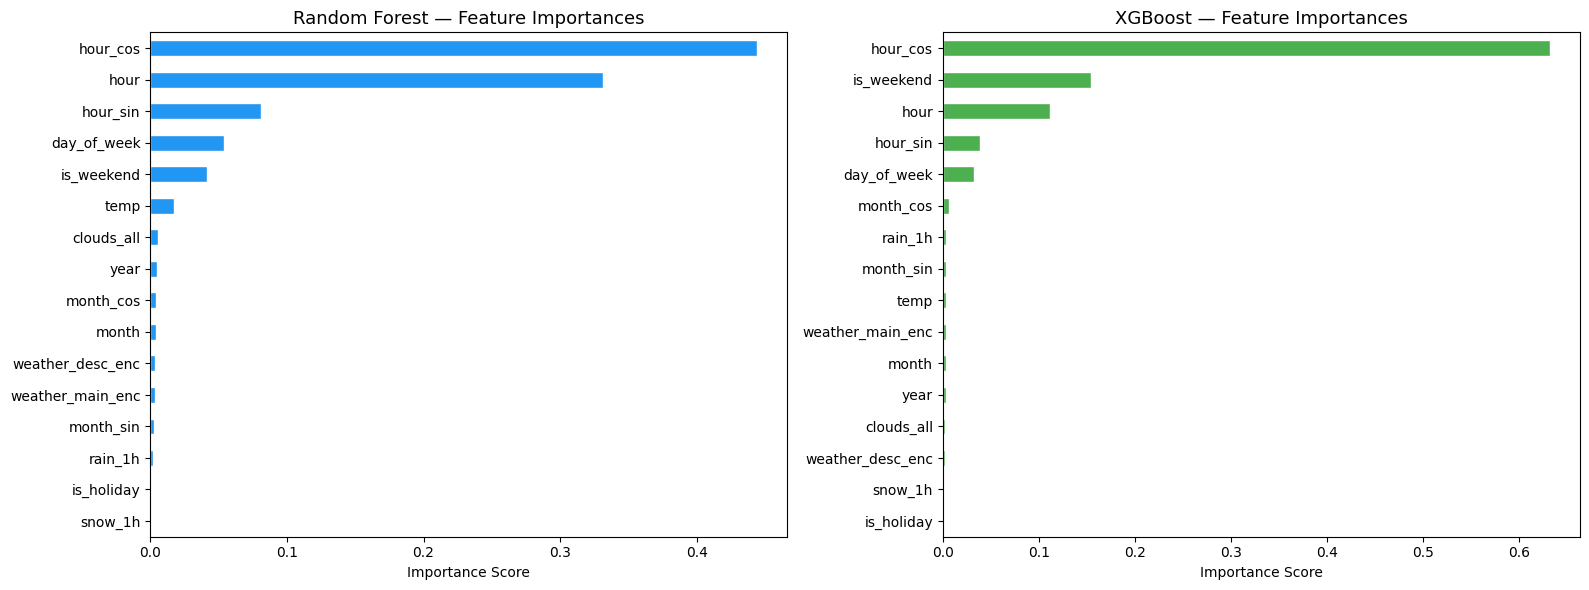

In [26]:
# ── 8d. Feature Importance (RF & XGBoost only — AdaBoost uses uniform weights) ─
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, (model, name, color) in zip(axes,
        [(rf_model, 'Random Forest', '#2196F3'),
         (xgb_model, 'XGBoost',      '#4CAF50')]):

    importances = pd.Series(model.feature_importances_, index=FEATURES)
    importances = importances.sort_values(ascending=True)
    importances.plot(kind='barh', ax=ax, color=color, edgecolor='white')
    ax.set_title(f'{name} — Feature Importances', fontsize=13)
    ax.set_xlabel('Importance Score')

plt.tight_layout()
plt.savefig('feature_importances.png', dpi=150, bbox_inches='tight')
plt.show()

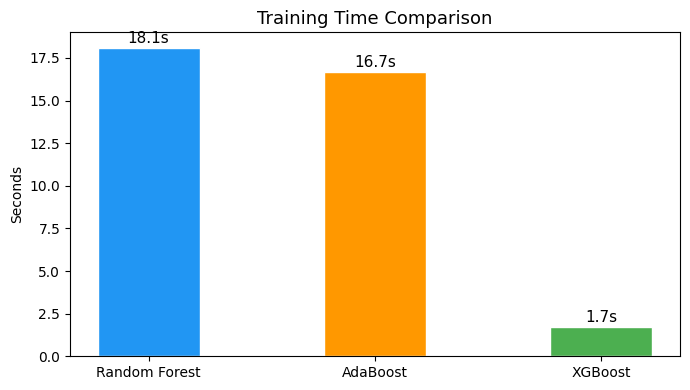

In [27]:
# ── 8e. Training Time comparison ─────────────────────────────────────
times = results_df['Train Time (s)']

plt.figure(figsize=(7, 4))
bars = plt.bar(times.index, times.values, color=colors, edgecolor='white', width=0.45)
for bar, v in zip(bars, times.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
             f'{v}s', ha='center', fontsize=11)
plt.title('Training Time Comparison', fontsize=13)
plt.ylabel('Seconds')
plt.tight_layout()
plt.savefig('training_time.png', dpi=150, bbox_inches='tight')
plt.show()

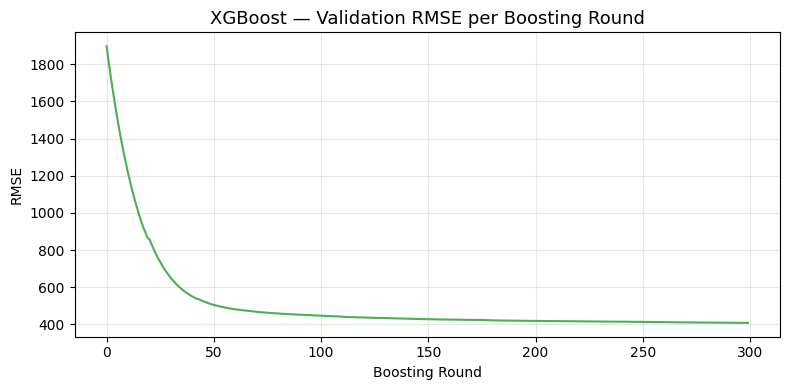

In [28]:
# ── 8f. XGBoost learning curve (RMSE vs boosting round) ──────────────
evals_result = xgb_model.evals_result()

plt.figure(figsize=(8, 4))
plt.plot(evals_result['validation_0']['rmse'], color='#4CAF50', lw=1.5)
plt.title('XGBoost — Validation RMSE per Boosting Round', fontsize=13)
plt.xlabel('Boosting Round')
plt.ylabel('RMSE')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('xgb_learning_curve.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. 🧠 Conclusion

| Model | Strengths | Weaknesses |
|-------|-----------|------------|
| **Random Forest** | Robust, parallel, handles outliers | Higher memory, slower prediction |
| **AdaBoost** | Simple, interpretable, good baseline | Sensitive to noise/outliers; sequential (slow) |
| **XGBoost** | Best accuracy, regularisation, speed | More hyperparameters to tune |

### Key Takeaways
- **XGBoost** typically achieves the **lowest RMSE and highest R²** on this traffic volume dataset because gradient boosting corrects errors iteratively and the built-in regularisation (`reg_alpha`, `reg_lambda`) prevents overfitting.
- **Random Forest** is a strong runner-up and is easier to tune — a great default ensemble method.
- **AdaBoost** uses shallow decision stumps by default; it may underfit on this complex time-series-like problem. Switching to deeper base estimators improves it.
- The most predictive features are **hour** (rush hours) and **day_of_week** (weekday vs. weekend), confirming that traffic patterns are driven primarily by time.

---
